# Machine Learning-Based Predictive Analytics for Energy Consumption in Smart Grids using Big Data

**Author:** Doaa Abduallah Abdeen | **Course:** ICTS 6339 Big Data, IUG

**Dataset:** [UCI Household Power Consumption](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption)

**GitHub:** https://github.com/doaaabdeen/BigData


In [7]:
!pip install -q pyspark matplotlib seaborn scikit-learn pandas


In [8]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName("SmartGrid").config("spark.driver.memory","4g").getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)


Spark 4.0.2


In [9]:

import time, json, numpy as np, pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA_FILE = "household_power_consumption.txt"
if not Path(DATA_FILE).exists():
    !wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip
    !unzip -q household_power_consumption.zip

def load_data(path):
    t0 = time.time()
    df = pd.read_csv(path, sep=';', na_values=['?'], low_memory=False)
    df.columns = ['Date','Time','Global_active_power','Global_reactive_power','Voltage',
                  'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
    df['DateTime'] = pd.to_datetime(df['Date']+' '+df['Time'], format='mixed', dayfirst=True)
    df = df.dropna(subset=['Global_active_power','DateTime'])
    print(f"Loaded {len(df):,} rows in {time.time()-t0:.1f}s")
    return df

def engineer_features(df):
    df = df.copy()
    df['hour'] = df['DateTime'].dt.hour
    df['day_of_week'] = df['DateTime'].dt.dayofweek
    df['month'] = df['DateTime'].dt.month
    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
    df['dow_sin'] = np.sin(2*np.pi*df['day_of_week']/7)
    df['dow_cos'] = np.cos(2*np.pi*df['day_of_week']/7)
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['is_weekend'] = (df['day_of_week']>=5).astype(int)
    df = df.sort_values('DateTime').reset_index(drop=True)
    for lag in [1,3,6,24]:
        df[f'lag_{lag}h_active_power'] = df['Global_active_power'].shift(lag)
    for lag in [1,3]:
        df[f'lag_{lag}h_sub_1'] = df['Sub_metering_1'].shift(lag)
    for w in [3,6,24]:
        df[f'rolling_mean_{w}h'] = df['Global_active_power'].rolling(w, min_periods=1).mean()
    df['total_sub_metering'] = df[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].sum(axis=1)
    feature_cols = ['Global_reactive_power','Voltage','Global_intensity',
        'Sub_metering_1','Sub_metering_2','Sub_metering_3',
        'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos','is_weekend',
        'lag_1h_active_power','lag_3h_active_power','lag_6h_active_power','lag_24h_active_power',
        'lag_1h_sub_1','lag_3h_sub_1','rolling_mean_3h','rolling_mean_6h','rolling_mean_24h','total_sub_metering']
    df = df.dropna(subset=feature_cols+['Global_active_power'])
    return df, feature_cols

df = load_data(DATA_FILE)
df, feature_cols = engineer_features(df)
X = df[feature_cols].values
y = df['Global_active_power'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train", len(X_train), "Test", len(X_test))


Loaded 2,049,280 rows in 175.6s
Train 1639404 Test 409852


In [10]:

def train_sklearn_models(X_train, X_test, y_train, y_test):
    models = {
        'LinearRegression': LinearRegression(),
        'RandomForest': RandomForestRegressor(n_estimators=30, max_depth=10, n_jobs=-1, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=50, max_depth=5, learning_rate=0.1, random_state=42),
    }
    results = {}
    for name, m in models.items():
        t0 = time.time()
        m.fit(X_train, y_train)
        tr = time.time()-t0
        pred = m.predict(X_test)
        results[name] = {
            'training_time_sec': round(tr,2),
            'metrics': {
                'RMSE': float(np.sqrt(mean_squared_error(y_test, pred))),
                'MAE': float(mean_absolute_error(y_test, pred)),
                'R2': float(r2_score(y_test, pred)),
            }
        }
        print(name, results[name])
    return results

sklearn_results = train_sklearn_models(X_train_s, X_test_s, y_train, y_test)
with open('pandas_benchmark.json','w') as f:
    json.dump({'num_rows_modeled': len(df), 'models': sklearn_results}, f, indent=2)


LinearRegression {'training_time_sec': 1.96, 'metrics': {'RMSE': 0.037357758554037224, 'MAE': 0.023195533203459177, 'R2': 0.9982616838199722}}
RandomForest {'training_time_sec': 353.53, 'metrics': {'RMSE': 0.03257416697031981, 'MAE': 0.017292631491342466, 'R2': 0.9986783581350919}}
GradientBoosting {'training_time_sec': 633.63, 'metrics': {'RMSE': 0.02946886668736468, 'MAE': 0.01741169167596997, 'R2': 0.9989183319074192}}


## Apache Spark MLlib (Big Data Environment)

In [11]:

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression as SparkLR, RandomForestRegressor as SparkRF, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

pdf = df[feature_cols + ['Global_active_power','DateTime']].copy()
pdf['ts'] = pdf['DateTime'].astype('int64')//10**9
sdf = spark.createDataFrame(pdf.drop(columns=['DateTime']))
sdf = sdf.withColumnRenamed('Global_active_power','label')
boundary = sdf.approxQuantile('ts', [0.8], 0.0)[0]
train_sdf = sdf.filter(sdf.ts <= boundary)
test_sdf = sdf.filter(sdf.ts > boundary)
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

spark_models = {
    'SparkLinearRegression': SparkLR(featuresCol='features', labelCol='label', maxIter=50),
    'SparkRandomForest': SparkRF(featuresCol='features', labelCol='label', numTrees=30, maxDepth=10, seed=42),
    'SparkGBT': GBTRegressor(featuresCol='features', labelCol='label', maxIter=50, maxDepth=5, seed=42),
}
evaluator = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse')
spark_results = {}
for name, algo in spark_models.items():
    pipe = Pipeline(stages=[assembler, algo])
    t0 = time.time()
    fitted = pipe.fit(train_sdf)
    tr = time.time()-t0
    pred = fitted.transform(test_sdf)
    rmse = evaluator.evaluate(pred)
    spark_results[name] = {'training_time_sec': round(tr,2), 'metrics': {'RMSE': round(rmse,6)}}
    print(name, spark_results[name])

with open('spark_benchmark.json','w') as f:
    json.dump({'platform':'pyspark','spark_version': spark.version, 'models': spark_results}, f, indent=2)


SparkLinearRegression {'training_time_sec': 47.67, 'metrics': {'RMSE': 0.037323}}
SparkRandomForest {'training_time_sec': 231.49, 'metrics': {'RMSE': 0.080509}}
SparkGBT {'training_time_sec': 624.31, 'metrics': {'RMSE': 0.079478}}


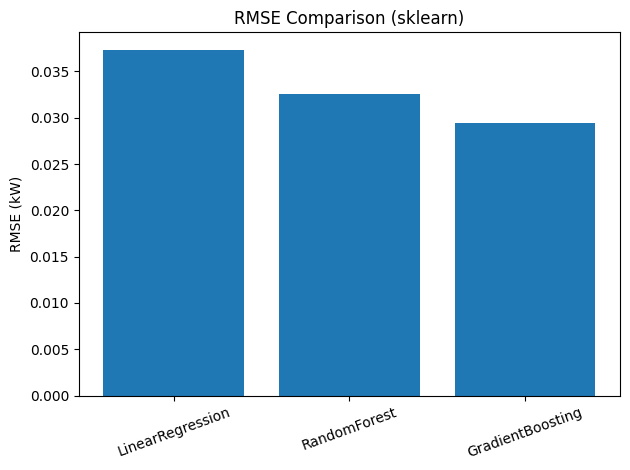

Best: GradientBoosting


In [12]:

import matplotlib.pyplot as plt
models = list(sklearn_results.keys())
rmse = [sklearn_results[m]['metrics']['RMSE'] for m in models]
plt.bar(models, rmse)
plt.title('RMSE Comparison (sklearn)')
plt.ylabel('RMSE (kW)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fig_rmse.png', dpi=150)
plt.show()
print('Best:', min(sklearn_results, key=lambda k: sklearn_results[k]['metrics']['RMSE']))


In [13]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

def fig1_dataset(df: pd.DataFrame, out: str = "fig1_dataset_patterns.png"):
    d = df.copy()
    d["hour"] = d["DateTime"].dt.hour
    d["dow"] = d["DateTime"].dt.dayofweek
    d["month"] = d["DateTime"].dt.month

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    hourly = d.groupby("hour")["Global_active_power"].mean()
    axes[0, 0].plot(hourly.index, hourly.values, color="#2E86AB", lw=2)
    axes[0, 0].set_title("(a) Daily pattern (mean by hour)")
    axes[0, 0].set_xlabel("Hour")
    axes[0, 0].set_ylabel("kW")

    weekly = d.groupby("dow")["Global_active_power"].mean()
    axes[0, 1].bar(weekly.index, weekly.values, color="#55A868")
    axes[0, 1].set_title("(b) Weekly pattern (mean by day)")
    axes[0, 1].set_xticks(range(7))
    axes[0, 1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

    monthly = d.groupby("month")["Global_active_power"].mean()
    axes[1, 0].plot(monthly.index, monthly.values, "o-", color="#C44E52")
    axes[1, 0].set_title("(c) Monthly pattern")
    axes[1, 0].set_xlabel("Month")

    sample = d["Global_active_power"].dropna().sample(min(50000, len(d)), random_state=42)
    axes[1, 1].hist(sample, bins=60, color="#4C72B0", edgecolor="white")
    axes[1, 1].set_title("(d) Distribution of global active power")
    axes[1, 1].set_xlabel("kW")

    plt.suptitle("Dataset characteristics", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.close()
    print("Saved", out)


def fig2_rmse(sklearn_results: dict, out: str = "fig2_rmse_sklearn.png"):
    models = list(sklearn_results.keys())
    rmse = [sklearn_results[m]["metrics"]["RMSE"] for m in models]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(models, rmse, color=["#4C72B0", "#55A868", "#C44E52"])
    ax.set_ylabel("RMSE (kW)")
    ax.set_title("RMSE Comparison (sklearn)")
    ax.set_ylim(0, max(rmse) * 1.15)
    for b, v in zip(bars, rmse):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.0005, f"{v:.4f}", ha="center", fontsize=9)
    plt.xticks(rotation=15)
    best = models[int(np.argmin(rmse))]
    ax.text(0.5, -0.18, f"Best: {best}", transform=ax.transAxes, ha="center")
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.close()
    print("Saved", out)


def fig3_metrics(sklearn_results: dict, out: str = "fig3_metrics_sklearn.png"):
    models = list(sklearn_results.keys())
    rmse = [sklearn_results[m]["metrics"]["RMSE"] for m in models]
    mae = [sklearn_results[m]["metrics"]["MAE"] for m in models]
    r2 = [sklearn_results[m]["metrics"]["R2"] for m in models]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, vals, title, ylab in zip(
        axes,
        [rmse, mae, r2],
        ["(a) RMSE", "(b) MAE", "(c) R²"],
        ["kW", "kW", "R²"],
    ):
        ax.bar(models, vals, color=["#4C72B0", "#55A868", "#C44E52"])
        ax.set_title(title)
        ax.set_ylabel(ylab)
        ax.tick_params(axis="x", rotation=15)
    plt.suptitle("Model performance comparison (sklearn)", fontsize=11)
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.close()
    print("Saved", out)


def fig3_training(sklearn_results: dict, spark_results=None, out: str = "fig3_training_times.png"):
    models = list(sklearn_results.keys())
    t_sk = [sklearn_results[m]["training_time_sec"] for m in models]
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(models))
    ax.bar(x - 0.2, t_sk, 0.4, label="sklearn", color="#2E86AB")
    if spark_results:
        sp_order = ["SparkLinearRegression", "SparkRandomForest", "SparkGBT"]
        t_sp = [spark_results[n]["training_time_sec"] for n in sp_order if n in spark_results]
        ax.bar(x + 0.2, t_sp[: len(x)], 0.4, label="Spark MLlib", color="#A23B72")
    ax.set_xticks(x)
    ax.set_xticklabels(["Linear Reg.", "Random Forest", "Grad. Boosting"])
    ax.set_ylabel("Training time (s)")
    ax.set_title("Training time comparison")
    ax.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.close()
    print("Saved", out)


def fig4_scalability(df, feature_cols, out: str = "fig4_scalability_lr.png"):
    """LR training time vs data fraction (chronological)."""
    X = df[feature_cols].values
    y = df["Global_active_power"].values
    n = len(X)
    fracs = [0.25, 0.5, 0.75, 1.0]
    samples, times = [], []
    for f in fracs:
        cut = int(n * f)
        X_tr, y_tr = X[:cut], y[:cut]
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X_tr)
        t0 = time.time()
        LinearRegression().fit(Xs, y_tr)
        elapsed = time.time() - t0
        samples.append(cut)
        times.append(elapsed)
        print(f"  {int(f*100)}% -> {cut} samples, {elapsed:.2f}s")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(np.array(samples) / 1e6, times, "o-", color="#2E86AB", lw=2)
    axes[0].set_xlabel("Training samples (millions)")
    axes[0].set_ylabel("Time (s)")
    axes[0].set_title("(a) Training time vs samples")
    axes[0].grid(alpha=0.3)

    axes[1].bar([25, 50, 75, 100], times, color="#55A868")
    axes[1].set_xlabel("Data fraction (%)")
    axes[1].set_ylabel("Time (s)")
    axes[1].set_title("(b) Training time vs fraction")
    plt.suptitle("Data size scalability (Linear Regression)", fontsize=11)
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.close()
    print("Saved", out)


def generate_all(df, feature_cols, sklearn_results, spark_results=None):
    fig1_dataset(df)
    fig2_rmse(sklearn_results)
    fig3_metrics(sklearn_results)
    fig3_training(sklearn_results, spark_results)
    fig4_scalability(df, feature_cols)
    if spark_results:
        fig, ax = plt.subplots(figsize=(7, 4))
        names = list(spark_results.keys())
        rmse = [spark_results[n]["metrics"]["RMSE"] for n in names]
        ax.bar(names, rmse, color="#A23B72")
        ax.set_title("Spark MLlib RMSE")
        ax.set_ylabel("kW")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.savefig("fig_spark_rmse.png", dpi=200)
        plt.close()
        print("Saved fig_spark_rmse.png")


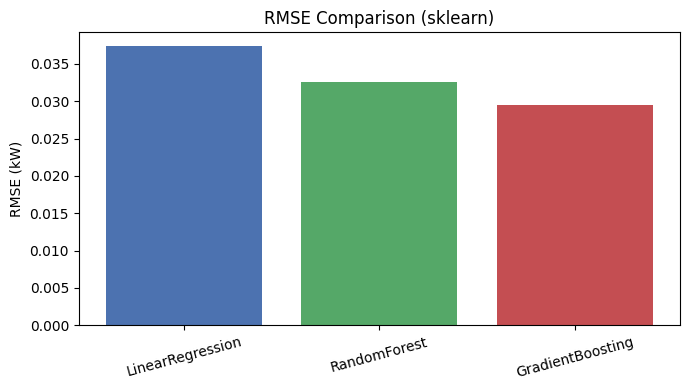

Saved: fig2_rmse_sklearn.png


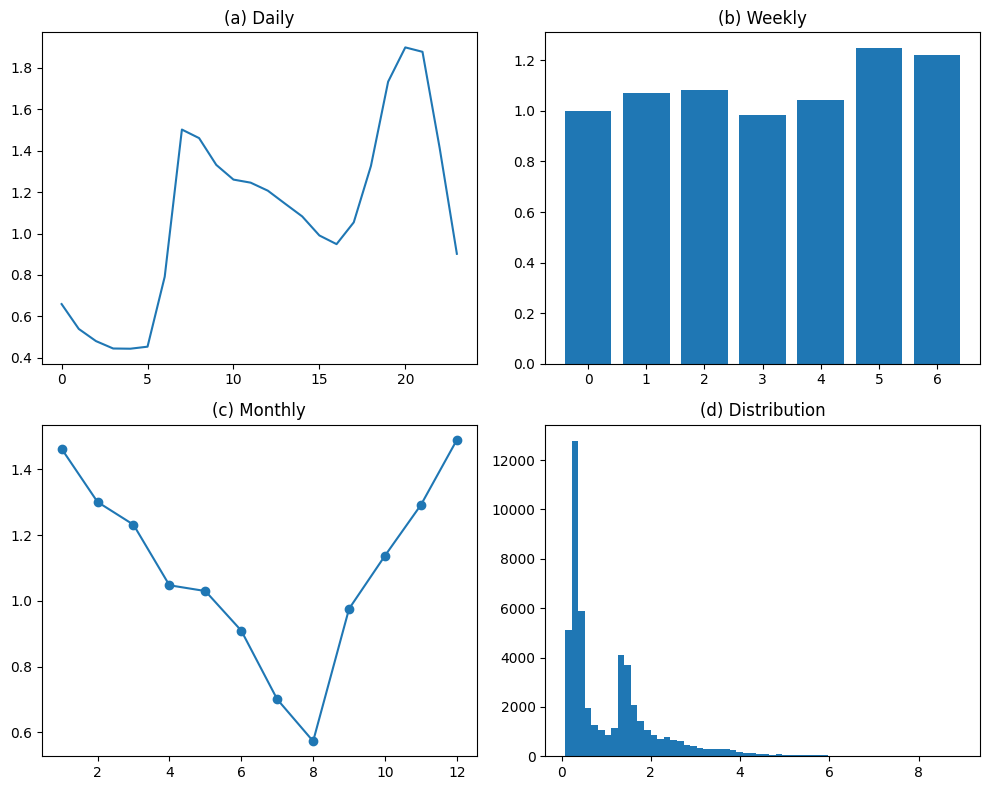

Saved: fig1_dataset_patterns.png


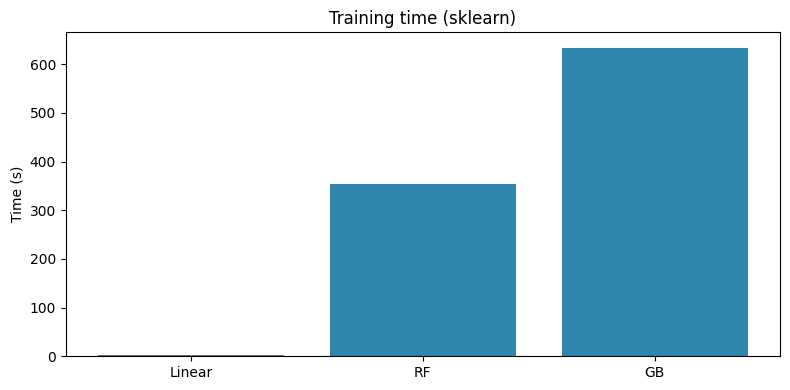

Saved: fig3_training_times.png

--- PNG files in /content ---
  fig1_dataset_patterns.png
  fig2_rmse_sklearn.png
  fig3_training_times.png
  fig_rmse.png


In [14]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# تحميل النتائج من JSON إن لم يكن sklearn_results في الذاكرة
try:
    sklearn_results
except NameError:
    with open("pandas_benchmark.json") as f:
        data = json.load(f)
    sklearn_results = data["models"]

# --- Fig 2 (RMSE) ---
models = list(sklearn_results.keys())
rmse = [sklearn_results[m]["metrics"]["RMSE"] for m in models]
plt.figure(figsize=(7, 4))
plt.bar(models, rmse, color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("RMSE (kW)")
plt.title("RMSE Comparison (sklearn)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("fig2_rmse_sklearn.png", dpi=200)
plt.show()
print("Saved: fig2_rmse_sklearn.png")

# --- Fig 1  ---
try:
    d = df.copy()
    d["hour"] = d["DateTime"].dt.hour
    d["dow"] = d["DateTime"].dt.dayofweek
    d["month"] = d["DateTime"].dt.month
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes[0,0].plot(d.groupby("hour")["Global_active_power"].mean())
    axes[0,0].set_title("(a) Daily")
    axes[0,1].bar(range(7), d.groupby("dow")["Global_active_power"].mean())
    axes[0,1].set_title("(b) Weekly")
    axes[1,0].plot(d.groupby("month")["Global_active_power"].mean(), "o-")
    axes[1,0].set_title("(c) Monthly")
    axes[1,1].hist(d["Global_active_power"].sample(min(50000, len(d)), random_state=42), bins=60)
    axes[1,1].set_title("(d) Distribution")
    plt.tight_layout()
    plt.savefig("fig1_dataset_patterns.png", dpi=200)
    plt.show()
    print("Saved: fig1_dataset_patterns.png")
except NameError:
    print("شغّلي خلية تحميل البيانات أولاً (df غير موجود)")

# --- Fig 3 training ---
times = [sklearn_results[m]["training_time_sec"] for m in models]
plt.figure(figsize=(8, 4))
plt.bar(["Linear", "RF", "GB"], times, color="#2E86AB")
plt.ylabel("Time (s)")
plt.title("Training time (sklearn)")
plt.tight_layout()
plt.savefig("fig3_training_times.png", dpi=200)
plt.show()
print("Saved: fig3_training_times.png")

# List of files in content
import os
print("\n--- PNG files in /content ---")
for f in sorted(os.listdir("/content")):
    if f.endswith(".png"):
        print(" ", f)

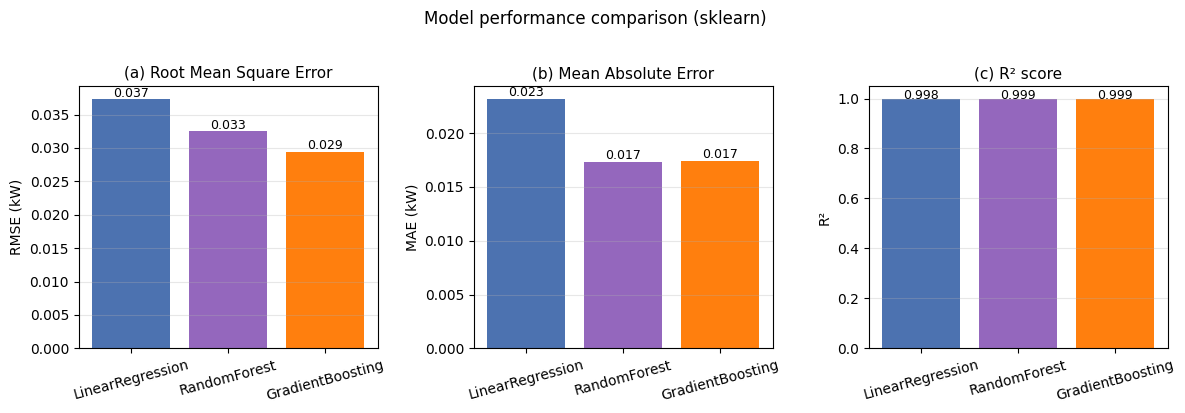

Saved: /content/fig2_model_metrics.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import json
import matplotlib.pyplot as plt
import numpy as np

try:
    res = sklearn_results
except NameError:
    with open("pandas_benchmark.json") as f:
        res = json.load(f)["models"]

models = list(res.keys())
rmse = [res[m]["metrics"]["RMSE"] for m in models]
mae  = [res[m]["metrics"]["MAE"]  for m in models]
r2   = [res[m]["metrics"]["R2"]   for m in models]

colors = ["#4C72B0", "#9467BD", "#FF7F0E"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, vals, title, ylab in zip(
    axes,
    [rmse, mae, r2],
    ["(a) Root Mean Square Error", "(b) Mean Absolute Error", "(c) R² score"],
    ["RMSE (kW)", "MAE (kW)", "R²"],
):
    bars = ax.bar(models, vals, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylab)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.0003, f"{v:.3f}", ha="center", fontsize=9)

plt.suptitle("Model performance comparison (sklearn)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig2_model_metrics.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/fig2_model_metrics.png")

from google.colab import files
files.download("fig2_model_metrics.png")

25% -> 512314 samples, 0.43 s
50% -> 1024628 samples, 0.99 s
75% -> 1536942 samples, 1.86 s
100% -> 2049256 samples, 3.23 s


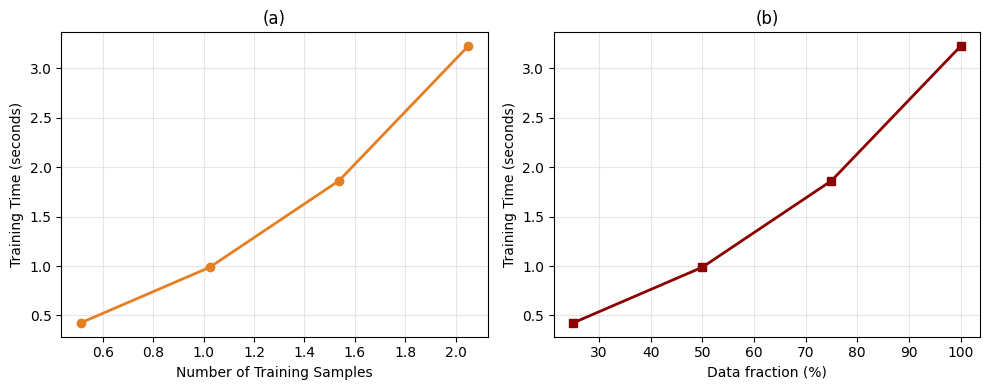

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
X = df[feature_cols].values
y = df["Global_active_power"].values
n = len(X)
samples, times, fracs_pct = [], [], []
for f in [0.25, 0.5, 0.75, 1.0]:
    cut = int(n * f)
    Xs = StandardScaler().fit_transform(X[:cut])
    t0 = time.time()
    LinearRegression().fit(Xs, y[:cut])
    elapsed = time.time() - t0
    samples.append(cut)
    times.append(elapsed)
    fracs_pct.append(int(f * 100))
    print(f"{int(f*100)}% -> {cut} samples, {elapsed:.2f} s")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(np.array(samples) / 1e6, times, "o-", color="#E67E22", lw=2)
axes[0].set_xlabel("Number of Training Samples")
axes[0].set_ylabel("Training Time (seconds)")
axes[0].set_title("(a)")
axes[0].grid(alpha=0.3)
axes[1].plot(fracs_pct, times, "s-", color="#8B0000", lw=2)
axes[1].set_xlabel("Data fraction (%)")
axes[1].set_ylabel("Training Time (seconds)")
axes[1].set_title("(b)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig4_scalability_lr.png", dpi=200)
plt.show()
from google.colab import files
files.download("fig4_scalability_lr.png")